### Отчёт по проекту временных рядов

#### Распределение ролей в команде

В работе над проектом участвовали три человека:

**Участник 1:** 
- загрузка и парсинг датасета M4 Daily (формат TSF)
- фильтрация и сэмплинг рядов по критерию силы сезонности (ACF)
- построение панельного датафрейма для глобальной модели, написание модуля `src/data_loader.py`

**Участник 2** 
- проектирование признаков (`src/features.py`)
- реализация глобального CatBoost-прогнозировщика с first-differencing и MAD-нормировкой (`src/models/catboost_model.py`)
- настройка гиперпараметров, запуск экспериментов (`run_experiment.py`, `src/experiments.py`)

**Участник 3:** 
- постановка гипотез, расчёт метрик качества (`src/evaluation.py`)
- реализация бейзлайнов (`src/models/`)
- анализ результатов, построение графиков (`analysis_results.ipynb`) и написание отчёта

---

## 1. Постановка задачи и гипотеза

Сезонность — один из ключевых паттернов в временных рядах. Для её моделирования существует несколько подходов: явные лаговые признаки с сезонными сдвигами, календарные категориальные признаки и Фурье-разложение периодических компонент.

**Гипотеза:** 
- добавление явных признаков сезонности (сезонные лаги, календарные переменные, Фурье-признаки) улучшит точность прогноза глобальной CatBoost-модели по сравнению с использованием только обычных лагов. Выигрыш будет значительнее для рядов с более сильной сезонностью и на более коротких горизонтах прогнозирования.

Эксперимент позволяет ответить на три подвопроса:

1. Какой тип признаков наиболее полезен для моделирования недельной сезонности?
2. Зависит ли эффект от силы сезонности (измеренной через |ACF|)?
3. Как изменяется улучшение при увеличении горизонта прогноза с 7 до 14 дней?

---

## 2. Описание данных

Использован датасет **M4 Daily**. Датасет содержит **4 227** ежедневных временных ряда из шести доменов: финансовые, макроэкономические, микроэкономические, демографические, промышленные и прочие. Преобладают финансовые ряды с трендом (близкие к случайному блужданию).

**Критерии отбора для эксперимента:**
- Длина ряда ≥ 700 наблюдений (достаточно данных для разумного обучения)
- |ACF(lag=7)| ≥ 0.20 — наличие статистически значимой недельной сезонности

После фильтрации в выборку попали **2 745** рядов, из которых случайно (random_seed=42) отобраны **150 рядов** для экспериментов.

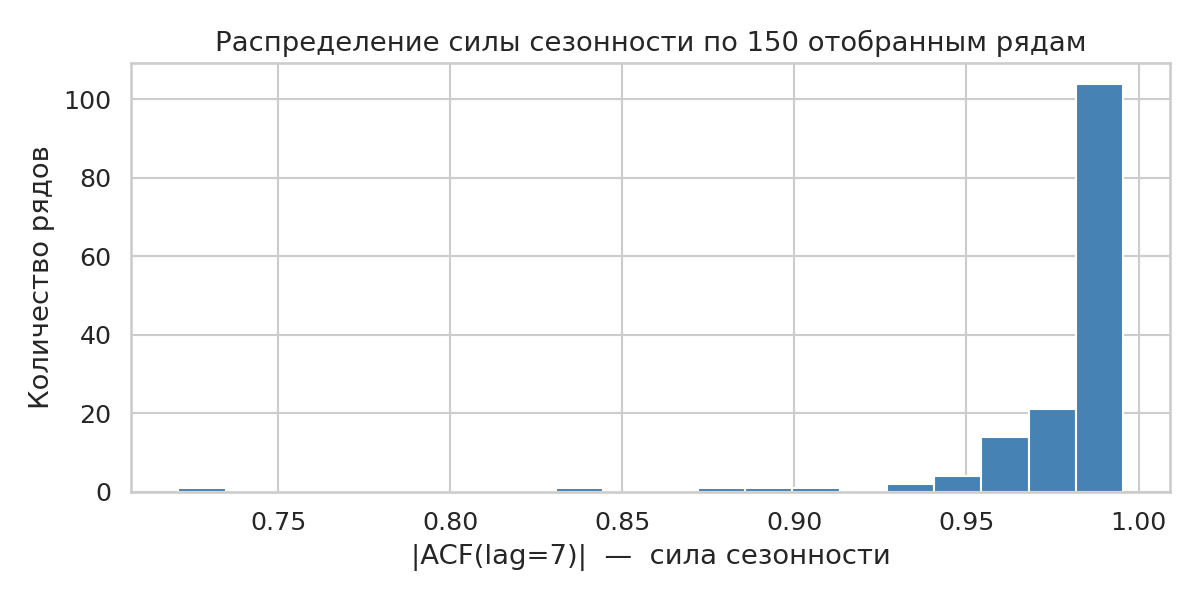

Рис. 1. Распределение силы сезонности (|ACF(7)|) по 150 отобранным рядам.


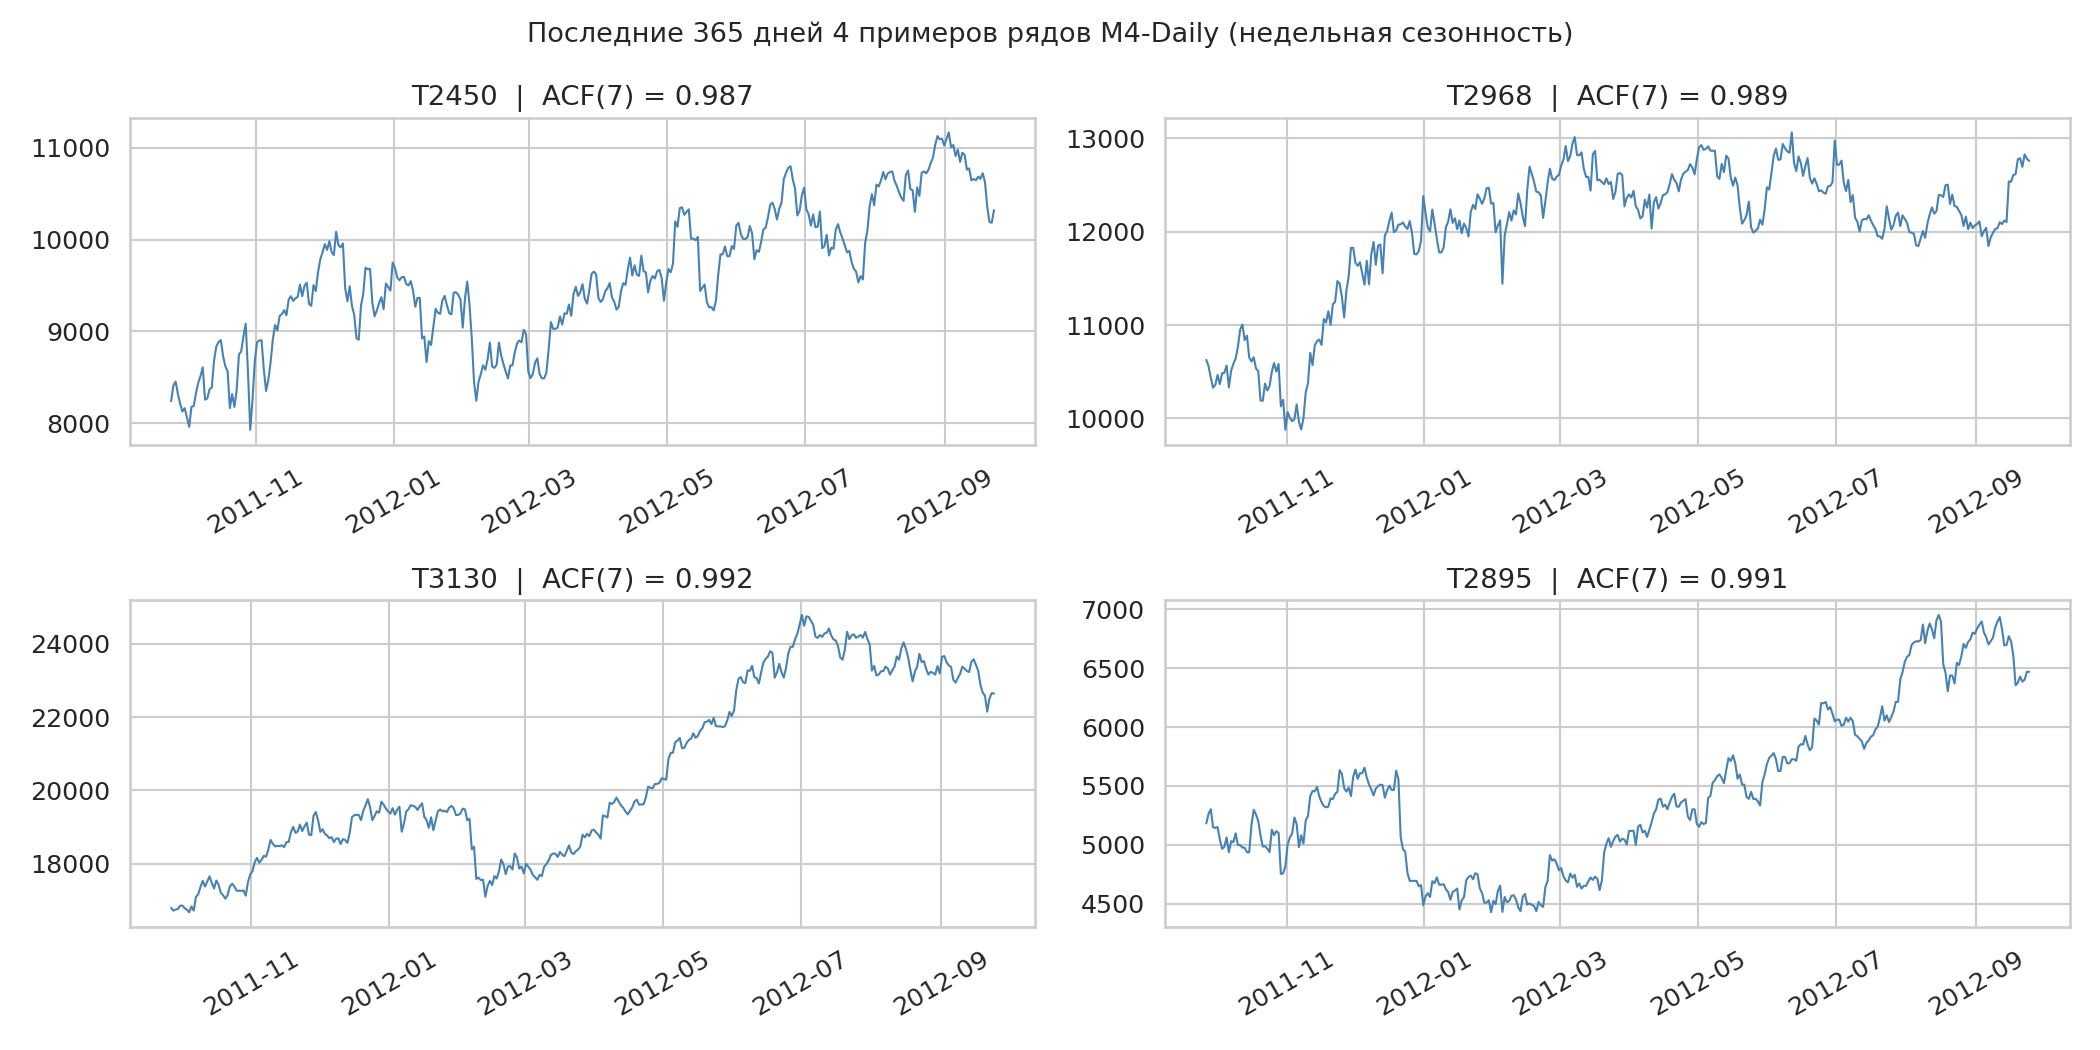

Рис. 2. Последние 365 дней четырёх случайных рядов из выборки.


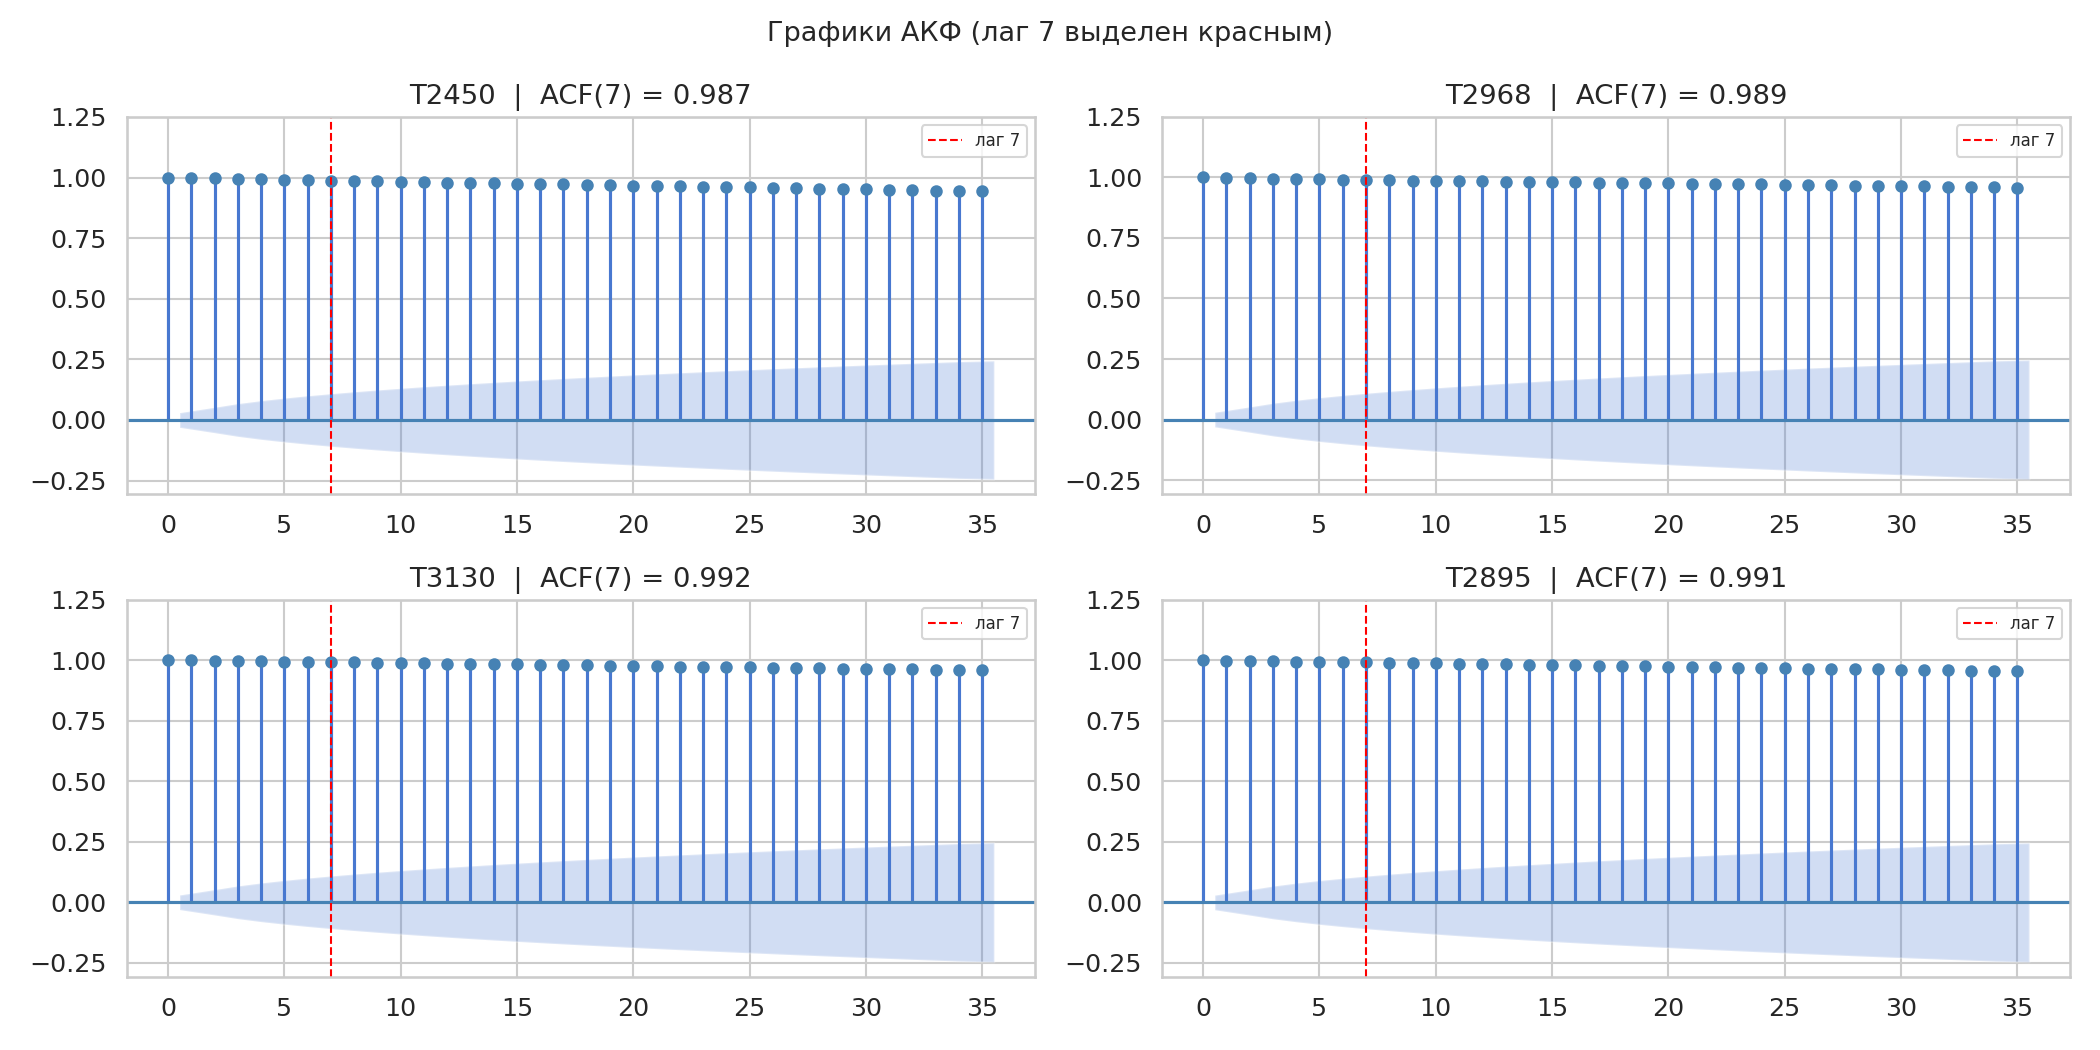

Рис. 3. ACF для тех же рядов (вертикальная пунктирная линия — лаг 7).


In [1]:
from IPython.display import Image, display
from pathlib import Path
import pandas as pd

FIGURES = Path("results/figures")

display(Image(str(FIGURES / "seasonality_strength_dist.png"), width=700))
print("Рис. 1. Распределение силы сезонности (|ACF(7)|) по 150 отобранным рядам.")

display(Image(str(FIGURES / "sample_series.png"), width=800))
print("Рис. 2. Последние 365 дней четырёх случайных рядов из выборки.")

display(Image(str(FIGURES / "acf_plots.png"), width=800))
print("Рис. 3. ACF для тех же рядов (вертикальная пунктирная линия — лаг 7).")

---

## 3. Методология эксперимента

### 3.1 Протокол валидации

Для каждого ряда используется **hold-out** валидация: последние H наблюдений отложены как тестовая выборка (H ∈ {7, 14}), все предыдущие — для обучения. Это корректно имитирует реальный сценарий прогнозирования «вперёд на H шагов» и гарантирует, что тестовые наблюдения не использовались при подборе модели.

### 3.2 Ключевое решение: работа в пространстве первых разностей

Финансовые временные ряды (основная часть M4 Daily) являются нестационарными процессами, близкими к случайному блужданию. Глобальная модель, обученная на сырых уровнях, не способна обобщаться между рядами с разными масштабами цен; экспериментально получено резкое ухудшение (MASE 5–8 против ~1 у Naive).

**Решение:** CatBoost обучается на **первых разностях** `dy[t] = y[t] − y[t−1]`, нормированных на медианное абсолютное отклонение (MAD) каждого ряда. Это:
- убирает тренд и делает ряды приближённо стационарными;
- нормирует масштаб, исключая доминирование высоковолатильных рядов при обучении.

Прогноз восстанавливается в исходный масштаб через кумулятивную сумму:

$$\hat{y}_{T+h} = y_T + \text{MAD} \cdot \sum_{i=1}^{h} \widehat{dy}_{T+i}$$

### 3.3 Метрики

В качестве **основной метрики** выбран _MASE (Mean Absolute Scaled Error)_:

$$\text{MASE} = \frac{1}{H} \sum_{h=1}^{H} \frac{|y_{T+h} - \hat{y}_{T+h}|}{\dfrac{1}{T-7} \sum_{t=8}^{T} |y_t - y_{t-7}|}$$

- Знаменатель — средняя абсолютная ошибка сезонного Naive с лагом 7 на обучающей выборке. 
- Значение MASE < 1 означает, что модель превосходит сезонный Naive.

**Обоснование выбора MASE как основной метрики:**

1. **Масштабонезависимость:**
    - Нормировка на собственный бейзлайн каждого ряда позволяет корректно агрегировать ошибку по 150 рядам с принципиально разными ценовыми диапазонами. Простое усреднение MAE по рядам было бы нечестным: высоковолатильные ряды доминировали бы в итоге.
2. **Интерпретируемость.** 
    - Результат читается напрямую: MASE = 0.95 означает «ошибка модели на 5 % ниже, чем у сезонного Naive». Нет необходимости знать типичный масштаб ряда.
3. **Устойчивость к нулям.** 
    - Метрики типа MAPE и sMAPE дают бесконечные или нестабильные значения, когда фактическое значение ряда близко к нулю. MASE нормируется на ошибку бейзлайна, а не на уровень ряда, и потому лишена этой проблемы.
4. **Соответствие датасету.** 
    - MASE является официальной метрикой соревнований M4 и M5-Forecasting.

**Ранжирование моделей производится по MASE, вычисленной на разных горизонтах прогнозирования (например: MASE@H7 - оценка MASE на следующую неделю)**

---

#### Вспомогательные метрики

Дополнительно рассчитываются три метрики для многостороннего анализа ошибок:

| Метрика | Описание |
|---------|----------|
| **MAE** | Интерпретируемая абсолютная ошибка в единицах ряда |
| **RMSE** | Штрафует крупные выбросы |
| **sMAPE** | Нормирована на [0%, 200%], пригодна для сравнения рядов разного масштаба |
| **MASE** | Нормирована на сезонный Naive (лаг 7); значение < 1 означает превышение бейзлайна |

---

## 4. Описание моделей

### 4.1 Бейзлайны (локальные модели)

Каждый бейзлайн обучается и предсказывает независимо для каждого ряда:

| Модель | Описание |
|--------|----------|
| **Naive** | Повторяет последнее наблюдение на все H шагов |
| **SeasonalNaive** | Повторяет последний сезонный цикл (7 дней) |
| **AutoETS** | Автоматически выбирает параметры экспоненциального сглаживания по критерию AIC (statsforecast) |
| **AutoTheta** | Метод Theta с автоматическим выбором (statsforecast). На практике часто близок к Naive для финансовых рядов, но учитывает тренд |

### 4.2 Глобальная модель: CatBoost + 7 вариантов признаков
- Один CatBoost обучается на всех 150 рядах одновременно
- Прогнозирование рекурсивное: каждый следующий шаг использует предсказание предыдущего в качестве истории.

**Гиперпараметры:** 
- `iterations=500`,
- `learning_rate=0.05`
- `depth=6`
- `loss=RMSE`
- `early_stopping_rounds=50`

| Вариант | Описание | Кол-во признаков |
|---------|----------|:-----------------:|
| `lags_only` | лаги 1–6 | 6 |
| `lags_seasonal` | лаги 1–6 + лаги 7, 14, 21, 28 | 10 |
| `lags_calendar` | лаги 1–6 + день недели/месяца/квартала… | 11 |
| `lags_fourier` | лаги 1–6 + Фурье (T=7, K=3; T=365, K=5) | 22 |
| `lags_seasonal_calendar` | лаги 1–6 + сезонные лаги + календарь | 15 |
| `lags_seasonal_fourier` | лаги 1–6 + сезонные лаги + Фурье | 26 |
| `all_features` | всё вместе | 31 |

---

## 5. Результаты

### 5.1 Сводная таблица метрик

In [2]:
import pandas as pd

agg = pd.read_csv("results/aggregated_metrics.csv")
agg_pivot = agg.pivot(index="model", columns="horizon", values=["MAE", "RMSE", "sMAPE", "MASE"])
agg_pivot.columns = [f"{m}@H{h}" for m, h in agg_pivot.columns]
agg_pivot = agg_pivot.sort_values("MASE@H7").reset_index()

def highlight_best(df):
    best = df[["MAE@H7","MAE@H14","MASE@H7","MASE@H14"]].idxmin()
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col, idx in best.items():
        styles.loc[idx, col] = "font-weight: bold; color: green; background-color: #d5e8d4"
    return styles

agg_pivot.style\
    .apply(highlight_best, axis=None)\
    .format({c: "{:.4f}" for c in agg_pivot.columns if c != "model"})\
    .set_caption("Таблица 1. Средние метрики по 150 рядам (выделена лучшая строка)")

,model,MAE@H7,MAE@H14,RMSE@H7,RMSE@H14,sMAPE@H7,sMAPE@H14,MASE@H7,MASE@H14
0,CatBoost_lags_calendar,126.2427,201.1339,143.9554,247.9316,1.6802,2.7496,0.9532,1.3790
1,CatBoost_lags_seasonal_calendar,127.4793,201.8779,145.0702,248.4792,1.6830,2.7405,0.9584,1.3822
2,CatBoost_all_features,128.1022,203.1517,145.7492,249.8420,1.6864,2.7463,0.9612,1.3889
3,CatBoost_lags_fourier,131.2193,207.6785,148.7980,254.4109,1.7368,2.8080,0.9785,1.4141
4,CatBoost_lags_seasonal,131.1085,206.8846,148.7481,253.6070,1.7372,2.8005,0.9786,1.4108
5,CatBoost_lags_only,131.4416,207.8718,149.0037,254.5462,1.7422,2.8141,0.9798,1.4152
6,CatBoost_lags_seasonal_fourier,130.7557,205.1919,148.3560,251.8727,1.7293,2.7813,0.9814,1.4032
7,AutoTheta,134.0999,212.0122,151.5355,259.0001,1.7772,2.8671,0.9908,1.4392
8,Naive,134.2790,213.6011,151.9577,260.6915,1.7780,2.8856,0.9953,1.4488
9,SeasonalNaive,191.7741,262.0794,212.6934,309.1021,2.5109,3.5054,1.3517,1.7538


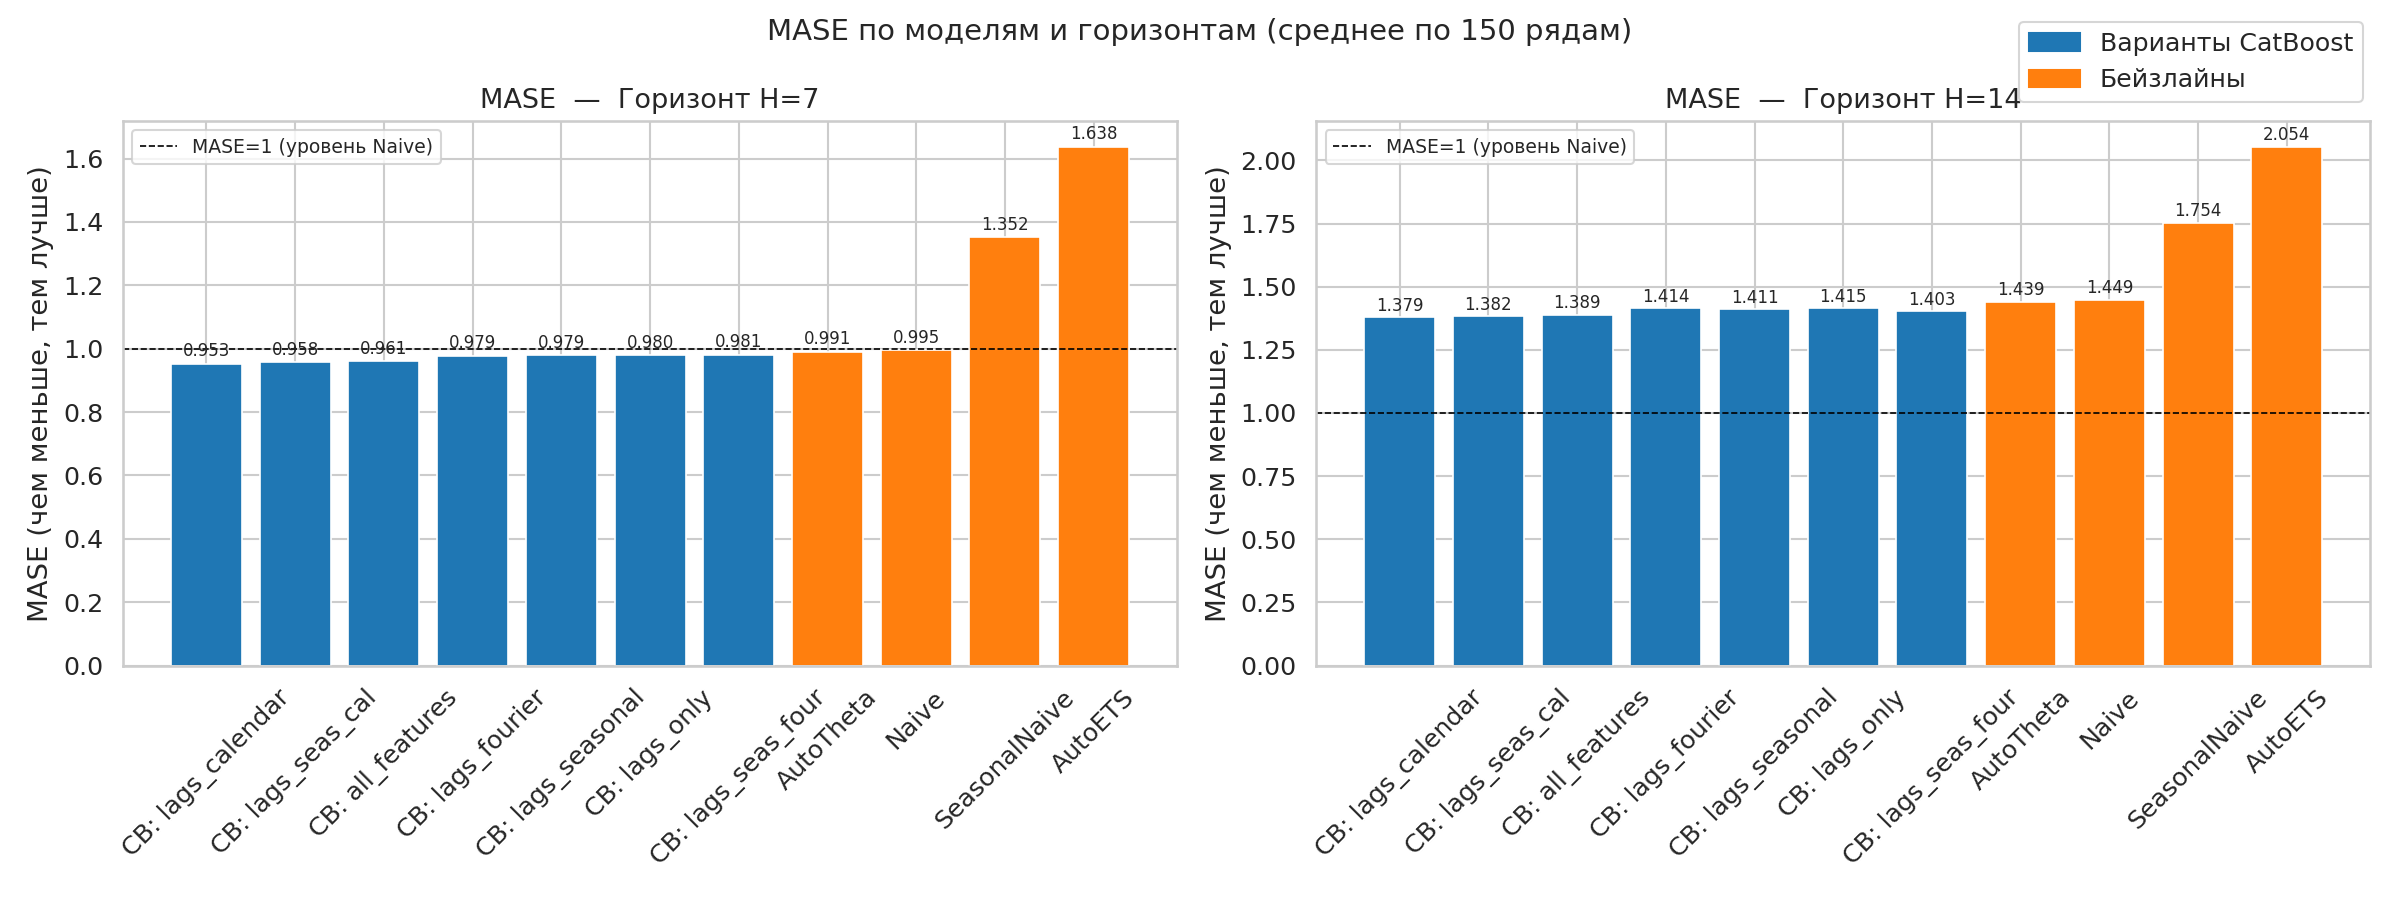

Рис. 4. MASE по всем моделям для H=7 и H=14. Синий = CatBoost-варианты, оранжевый = бейзлайны.


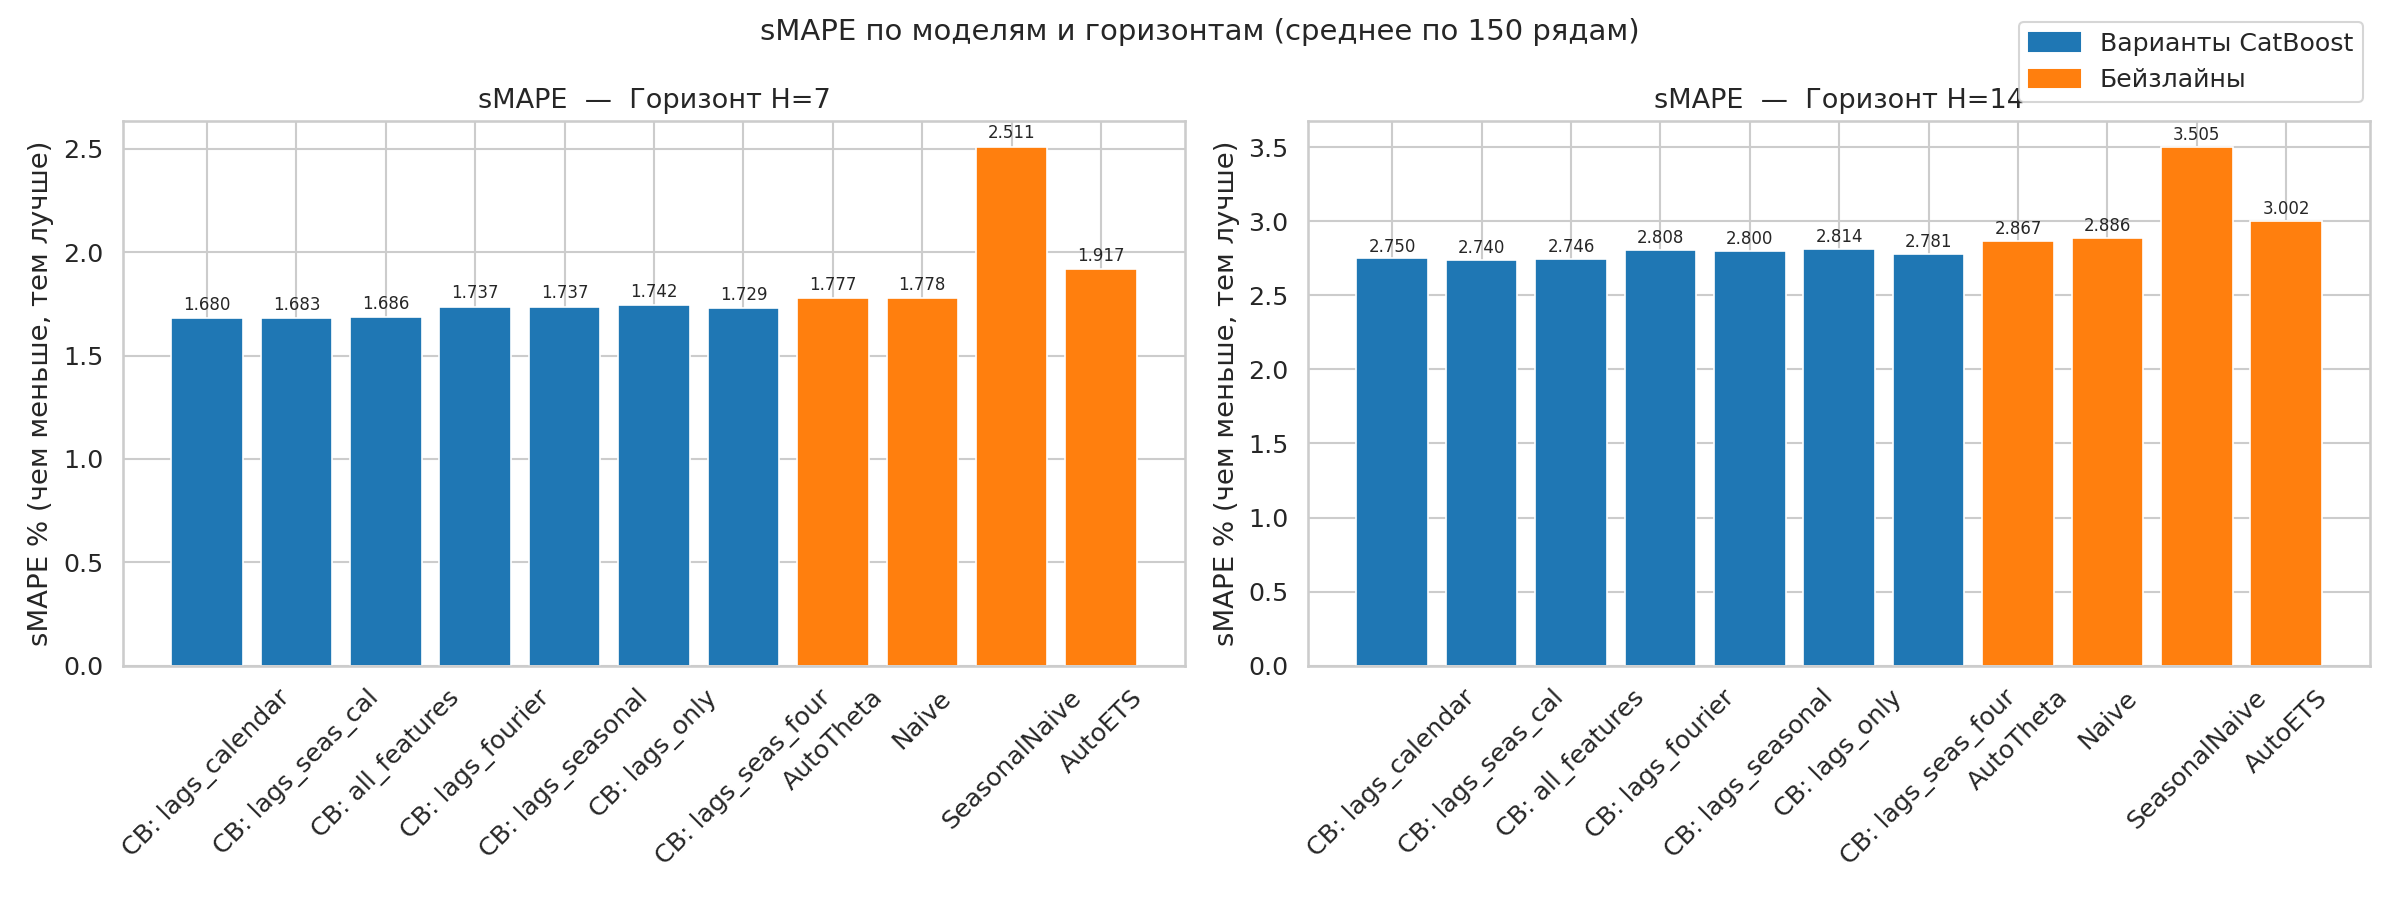

Рис. 5. sMAPE по всем моделям для H=7 и H=14.


In [4]:
from IPython.display import Image, display
from pathlib import Path
FIGURES = Path("results/figures")

display(Image(str(FIGURES / "mase_comparison.png"), width=900))
print("Рис. 4. MASE по всем моделям для H=7 и H=14. Синий = CatBoost-варианты, оранжевый = бейзлайны.")

display(Image(str(FIGURES / "smape_comparison.png"), width=900))
print("Рис. 5. sMAPE по всем моделям для H=7 и H=14.")

### 5.2 Влияние горизонта прогнозирования

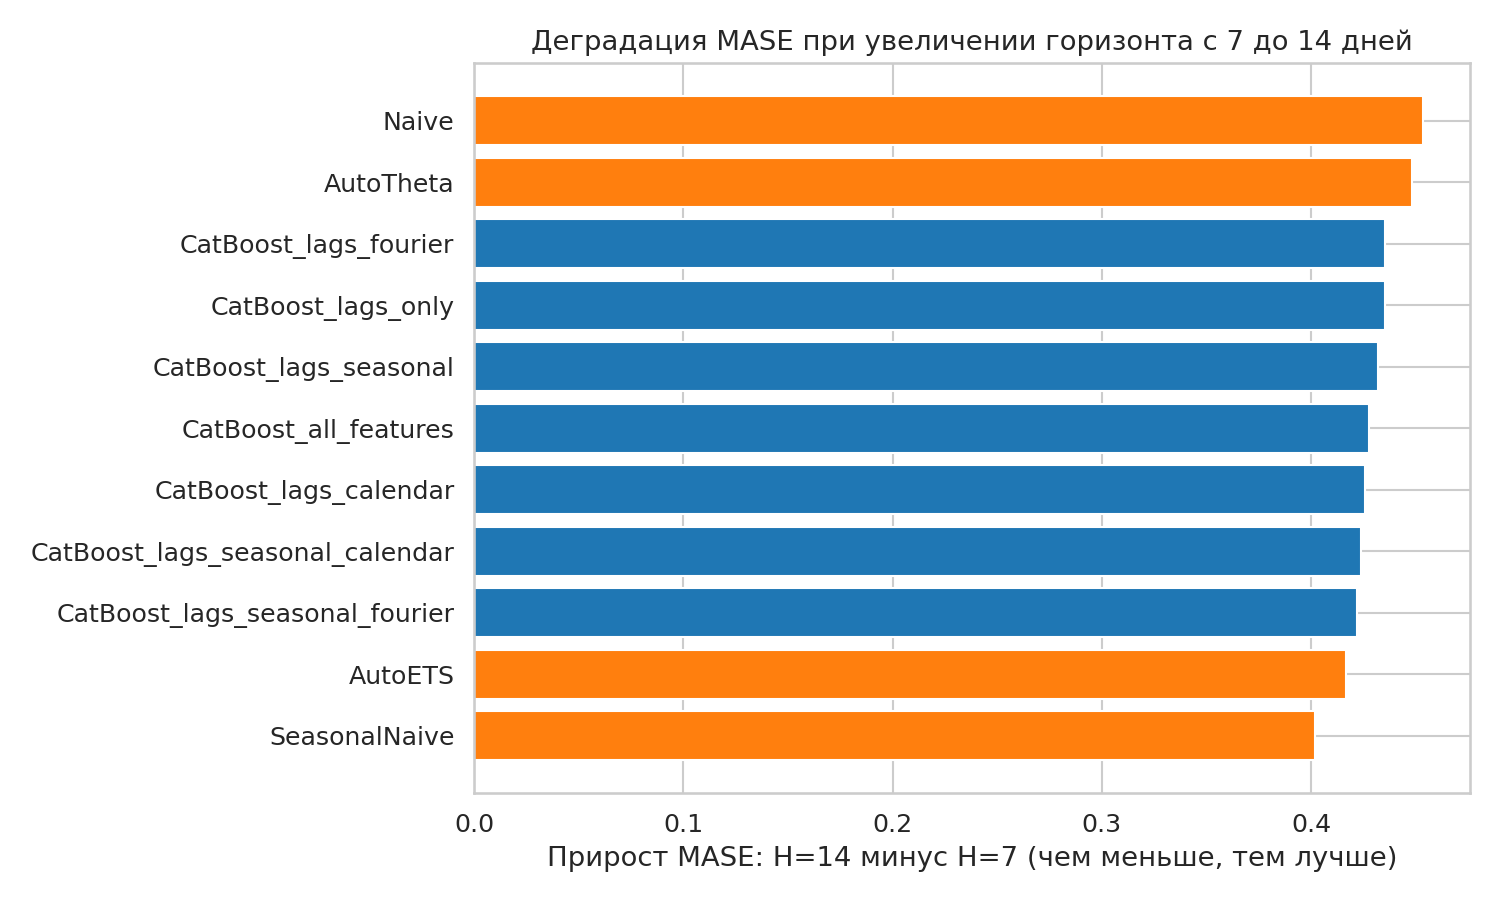

Рис. 6. Прирост MASE при увеличении горизонта с 7 до 14 дней.


In [5]:
display(Image(str(FIGURES / "horizon_degradation.png"), width=750))
print("Рис. 6. Прирост MASE при увеличении горизонта с 7 до 14 дней.")

### 5.3 Влияние силы сезонности

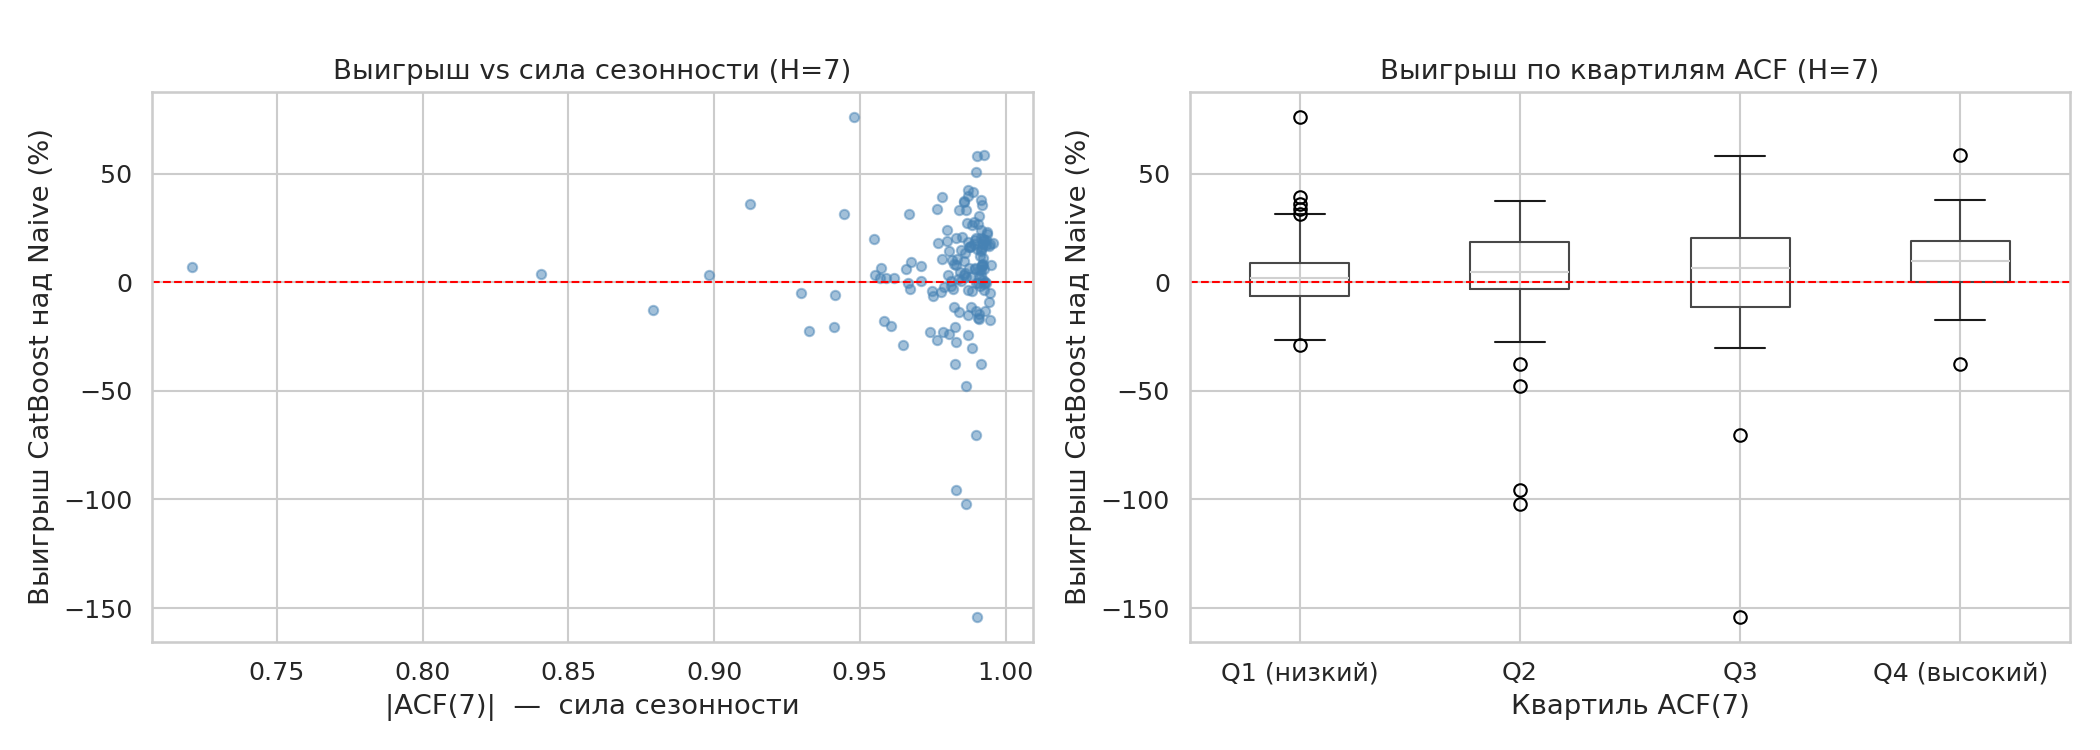

Рис. 7. Улучшение CatBoost lags_calendar над Naive в зависимости от |ACF(7)|.


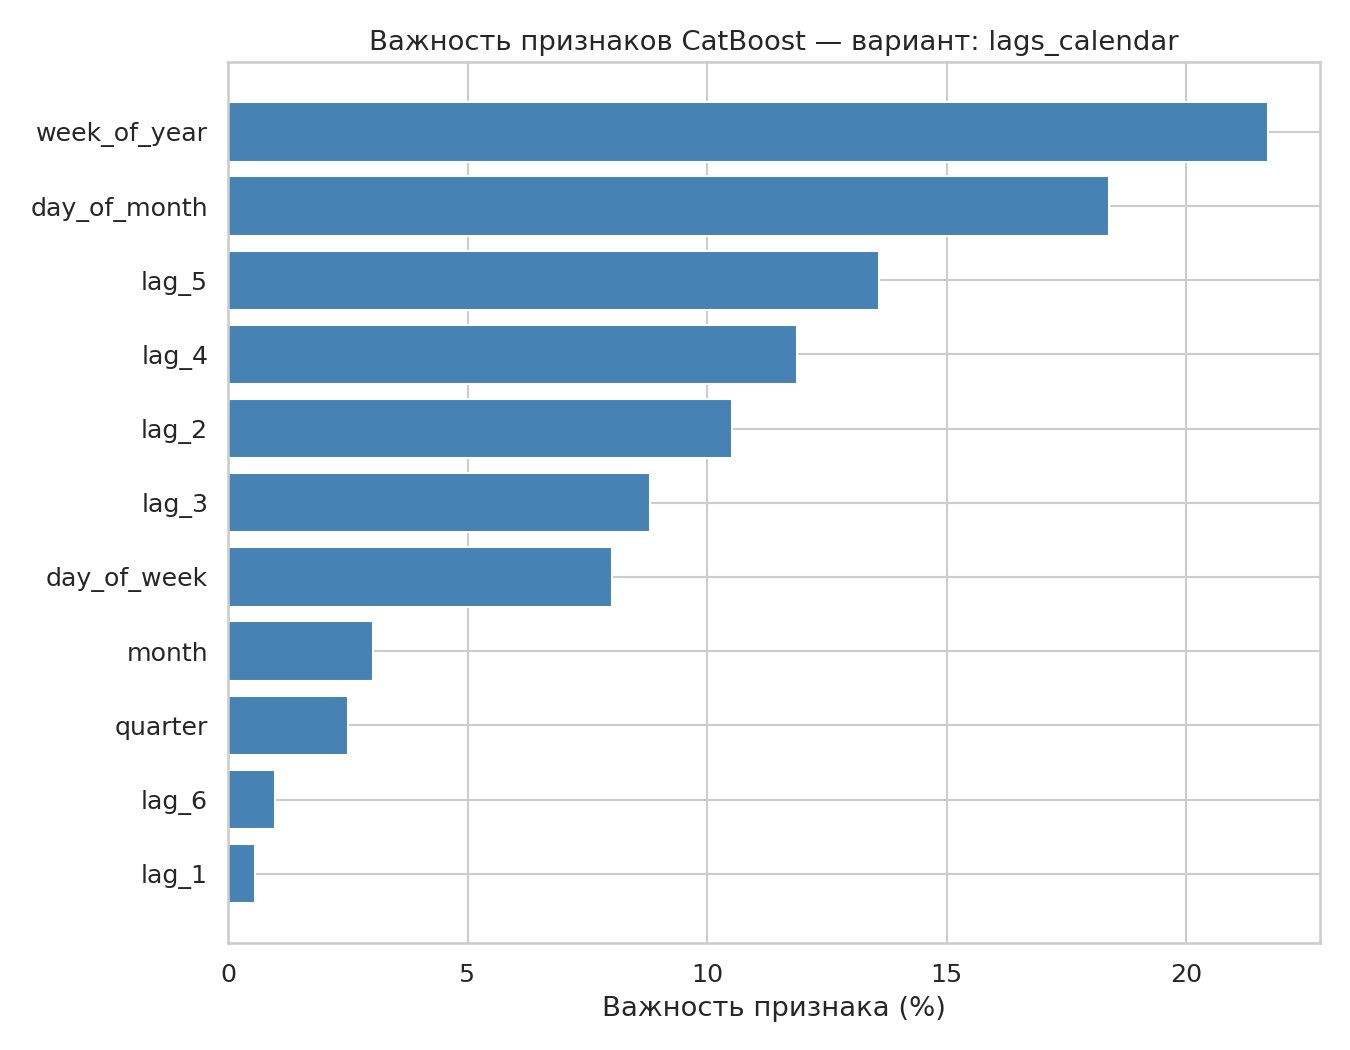

Рис. 8. Важность признаков CatBoost (вариант lags_calendar).


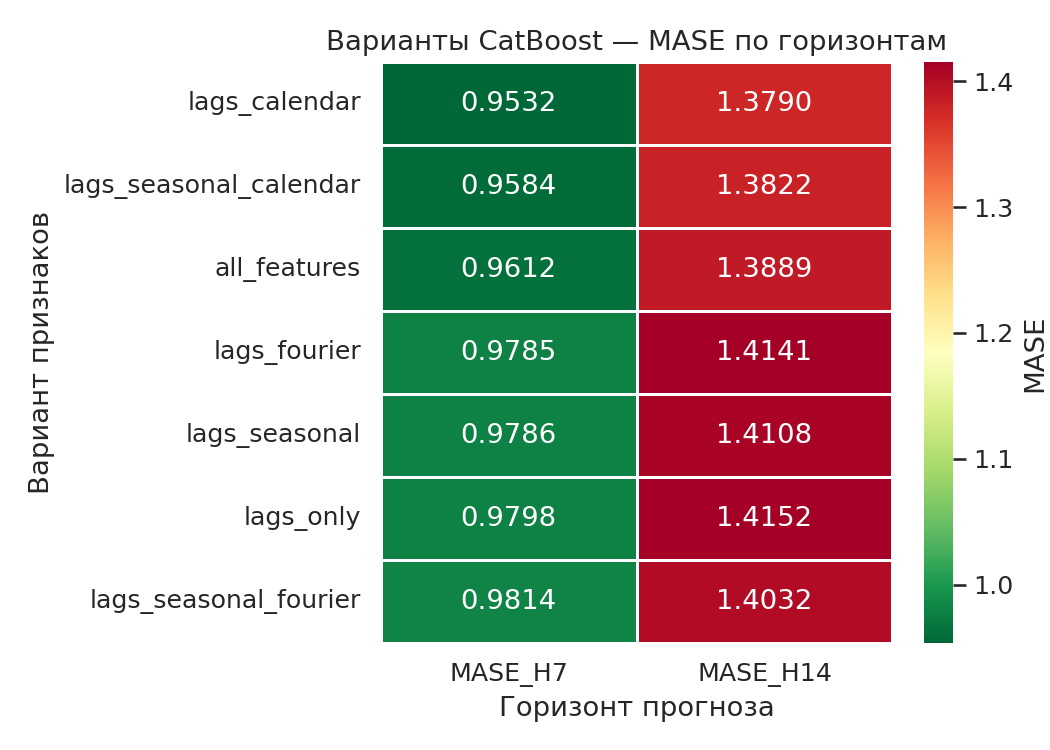

Рис. 9. MASE для 7 вариантов CatBoost при H=7 и H=14 (меньше = лучше).


In [6]:
display(Image(str(FIGURES / "seasonality_effect.png"), width=900))
print("Рис. 7. Улучшение CatBoost lags_calendar над Naive в зависимости от |ACF(7)|.")

display(Image(str(FIGURES / "feature_importance.png"), width=750))
print("Рис. 8. Важность признаков CatBoost (вариант lags_calendar).")

display(Image(str(FIGURES / "variant_heatmap.png"), width=700))
print("Рис. 9. MASE для 7 вариантов CatBoost при H=7 и H=14 (меньше = лучше).")

---

## 6. Выводы

### 6.1 Главный результат

Лучшим вариантом признаков оказался **lags_calendar** (лаги 1–6 + день недели, день месяца, месяц, номер недели, квартал). Его MASE = **0.9532** при H=7 и **1.379** при H=14, что лучше, чем у Naive (0.995 / 1.449) и AutoTheta (0.991 / 1.439) — сильнейших бейзлайнов для этих данных.

---

### 6.2 Результаты исследований

**Какой тип признаков наиболее полезен?**
- Календарные признаки (категориальный день недели и аналогичные) дают прирост +2.7% MASE над чистыми лагами. Сезонные лаги добавляют лишь +0.1% при использовании без календаря. Фурье-признаки не дают нового сигнала поверх лагов — вероятно, из-за коллинеарности с lag-7. Комбинирование более чем двух типов признаков ухудшает результат из-за переобучения.

**Зависит ли эффект от силы сезонности?**
- Слабая зависимость: внутри отфильтрованной выборки (все ряды с |ACF7| ≥ 0.20) улучшение CatBoost над Naive не коррелирует с ACF-квартилем. Выигрыш объясняется кросс-рядовым переносом знаний, а не амплитудой сезонной компоненты.

**Зависит ли эффект от горизонта?**
- MASE CatBoost-вариантов вырастает примерно вдвое с H=7 до H=14, аналогично Naive. Относительное преимущество CatBoost сохраняется на обоих горизонтах. Да, зависит

---

### 6.3 О бейзлайнах

| Модель | Вывод |
|--------|-------|
| **Naive** | Сильный бейзлайн для финансовых рядов; глобальным моделям с трудом удаётся его превзойти без разностного преобразования |
| **SeasonalNaive** | Худший бейзлайн (MASE 1.35–1.75): финансовые ряды не воспроизводят точно паттерн прошлой недели на уровнях |
| **AutoETS** | Ещё хуже (MASE 1.64–2.05): ETS-модели склонны к большим ошибкам при сильном трендовом шуме |
| **AutoTheta** | Лучший одиночный бейзлайн (MASE 0.991 при H=7), конкурентоспособен с CatBoost без признаков сезонности |

---

### 6.4 Выводы по результатам экспериментов

Для прогнозирования ежедневных финансовых (и аналогичных трендовых) рядов с недельной сезонностью рекомендуется:

1. Применять **first-differencing** перед обучением глобальной модели
2. Использовать **календарные категориальные признаки** (особенно день недели) вместо Фурье или только сезонных лагов
3. Не перегружать модель признаками: `lags_calendar` лучше `all_features`
4. AutoTheta — хороший выбор, если глобальная модель не нужна (небольшой набор рядов)